# BEE 4750 Homework 4: Linear Programming and Capacity Expansion

**Name**: Eliana Olson

**ID**: ero23

> **Due Date**
>
> Thursday, 11/06/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to analytically (or graphically) solve a linear
    program.
-   Problem 2 asks you to formulate and solve a resource allocation
    problem using linear programming.
-   Problem 3 asks you to formulate, solve, and analyze a standard
    generating capacity expansion problem.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating 

project at `~/hw4-ero23_hw4`


In [2]:
using JuMP
using HiGHS
using DataFrames
using Plots
using Measures
using CSV
using MarkdownTables

## Problems (Total: 30 Points)

### Problem 1 (Total: 3 Points)

Solve the following linear program **analytically**. Show your work and
justify any reasoning.

$$
\begin{alignedat}{2}
&& \max_{x, y} \quad & 3x + 2y\\
&&\text{subject to:} \quad & x + 4y \leq 16\\
& && x - 2y \leq -1\\
& && 0 \leq x \leq 4\\
& && 1 \leq y \leq 4.
\end{alignedat}
$$

![Hand-drawn Graph of LP problem](HW4/graph.jpeg){ width=80% }

![Checked the analytic solution using excel solver](HW4/excel.png){ width=80% }


### Problem 2 (12 points)

A farmer has access to a pesticide which can be used on corn, soybeans,
and wheat fields, and costs \$70/kg-yr to apply. The crop yields the
farmer can obtain following crop yields by applying varying rates of
pesticides to the field are shown in
<a href="#tbl-yields" class="quarto-xref">Table 1</a>.

| Application Rate (kg/ha) | Soybean (kg/ha) | Wheat (kg/ha) | Corn (kg/ha) |
|:------------------------:|:---------------:|:-------------:|:------------:|
|            0             |      2900       |     3500      |     5900     |
|            1             |      3800       |     4100      |     6700     |
|            2             |      4400       |     4200      |     7900     |

Table 1: Crop yields from applying varying pesticide rates for Problem
1.

The costs of production, *excluding pesticides*, for each crop, and
selling prices, are shown in
<a href="#tbl-costs" class="quarto-xref">Table 2</a>.

|   Crop   | Production Cost (\$/ha-yr) | Selling Price (\$/kg) |
|:--------:|:--------------------------:|:---------------------:|
| Soybeans |            350             |         0.36          |
|  Wheat   |            280             |         0.27          |
|   Corn   |            390             |         0.22          |

Table 2: Costs of crop production, excluding pesticides, and selling
prices for each crop.

Recently, environmental authorities have declared that farms cannot have
an *average* application rate on soybeans, wheat, and corn which exceeds
0.8, 0.7, and 0.6 kg/ha, respectively. The farmer has asked you for
advice on how they should plant crops and apply pesticides to maximize
profits over 130 total ha while remaining in regulatory compliance if
demand for each crop (which is the maximum the market would buy) this
year is 250,000 kg?

#### Problem 2.1

Formulate a linear program for this resource allocation problem,
including clear definitions of decision variable(s) (including units),
objective function(s), and constraint(s) (make sure to explain functions
and constraints with any needed derivations and explanations). **Tip:
Make sure that all of your constraints are linear**.

In [3]:
farm_model = Model(HiGHS.Optimizer) # initialize model object
@variable(farm_model, S[0:2] >= 0) # non-negativity constraints
@variable(farm_model, W[0:2] >= 0)
@variable(farm_model, C[0:2] >= 0)

# Maximize profit
@objective(farm_model, Max, 694S[0]+948S[1]+1094S[2]+665W[0]+757W[1]+714W[2]+908C[0]+1014C[1]+1208C[2])

# Total land constraint
@constraint(farm_model, land, S[0]+S[1]+S[2]+W[0]+W[1]+W[2]+C[0]+C[1]+C[2] <= 130)

# Demand (must not exceed market limit)
@constraint(farm_model, soybean_max, 2900S[0]+3800S[1]+4400S[2] <= 250_000)
@constraint(farm_model, wheat_max, 3500W[0]+4110W[1]+4200W[2] <= 250_000)
@constraint(farm_model, corn_max, 5900C[0]+6700C[1]+7900C[2] <= 250_000)

# Pesticide average constraints (linearized)
@constraint(farm_model, -0.8 * S[0] + 0.2 * S[1] + 1.2 * S[2] <= 0)
@constraint(farm_model, -0.7 * W[0] + 0.3 * W[1] + 1.3 * W[2] <= 0)
@constraint(farm_model, -0.6 * C[0] + 0.4 * C[1] + 1.4 * C[2] <= 0)

print(farm_model) # this outputs a nicely formatted summary of the model so you can check your specification

Max 694 S[0] + 948 S[1] + 1094 S[2] + 665 W[0] + 757 W[1] + 714 W[2] + 908 C[0] + 1014 C[1] + 1208 C[2]


Subject to
 

land : S[0] + S[1] + S[2] + W[0] + W[1] + W[2] + C[0] + C[1] + C[2] ≤ 130
 soybean_max : 2900 S[0] + 3800 S[1] + 4400 S[2] ≤ 250000
 wheat_max : 3500 W[0] + 4110 W[1] + 4200 W[2] ≤ 250000
 corn_max : 5900 C[0] + 6700 C[1] + 7900 C[2] ≤ 250000
 -0.8 S[0] + 0.2 S[1] + 1.2 S[2] ≤ 0
 -0.7 W[0] + 0.3 W[1] + 1.3 W[2] ≤ 0
 -0.6 C[0] + 0.4 C[1] + 1.4 C[2] ≤ 0
 S[0] ≥ 0
 S[1] ≥ 0
 S[2] ≥ 0
 W[0] ≥ 0
 W[1] ≥ 0
 W[2] ≥ 0
 C[0] ≥ 0
 C[1] ≥ 0
 C[2] ≥ 0


In [4]:
optimize!(farm_model)

Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7 rows; 9 cols; 27 nonzeros
Coefficient ranges:
  Matrix [2e-01, 8e+03]
  Cost   [7e+02, 1e+03]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 2e+05]
Presolving model
7 rows, 9 cols, 27 nonzeros  0s
7 rows, 9 cols, 27 nonzeros  0s
Presolve : Reductions: rows 7(-0); columns 9(-0); elements 27(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.8170297740e+02 Ph1: 7(28.3649); Du: 9(181.703) 0s
          7     1.1674116702e+05 Pr: 0(0) 0s
Model status        : Optimal
Simplex   iterations: 7
Objective value     :  1.1674116702e+05
P-D objective error :  6.2325284535e-17
HiGHS run time      :          0.00


#### Problem 2.2

How many ha should the farmer dedicate to each crop and with what
pesticide application rate(s)? How much profit will the farmer expect to
make?

In [6]:
println("=== Optimal Land Allocation (hectares) ===")

println("\nSoybeans:")  
println("  S[0] (0 kg/ha pesticide)  = ", value(S[0]))  
println("  S[1] (1 kg/ha pesticide)  = ", value(S[1]))  
println("  S[2] (2 kg/ha pesticide)  = ", value(S[2]))  

println("\nWheat:")  
println("  W[0] (0 kg/ha pesticide)  = ", value(W[0]))  
println("  W[1] (1 kg/ha pesticide)  = ", value(W[1]))  
println("  W[2] (2 kg/ha pesticide)  = ", value(W[2]))  

println("\nCorn:")  
println("  C[0] (0 kg/ha pesticide)  = ", value(C[0]))  
println("  C[1] (1 kg/ha pesticide)  = ", value(C[1]))  
println("  C[2] (2 kg/ha pesticide)  = ", value(C[2]))  

=== Optimal Land Allocation (hectares) ===

Soybeans:
  S[0] (0 kg/ha pesticide)  = 13.812154696132604
  S[1] (1 kg/ha pesticide)  = 55.24861878453038
  S[2] (2 kg/ha pesticide)  = 0.0

Wheat:
  W[0] (0 kg/ha pesticide)  = 6.7433064173395625
  W[1] (1 kg/ha pesticide)  = 15.734381640458977
  W[2] (2 kg/ha pesticide)  = 0.0

Corn:
  C[0] (0 kg/ha pesticide)  = 26.92307692307692
  C[1] (1 kg/ha pesticide)  = 0.0
  C[2] (2 kg/ha pesticide)  = 11.538461538461547


In [7]:
println("\nTotal Maximum Profit = \$", objective_value(farm_model))


Total Maximum Profit = $116741.16702082448

#### Problem 2.3

The farmer has an opportunity to buy an extra 10 ha of land. How much
extra profit would this land be worth to the farmer? Discuss why this
value makes sense and under what conditions you would recommend the
farmer should make the purchase.

In [9]:
println("Shadow price of land constraint = ", shadow_price(land))  

println("Extra profit for 10 extra ha= \$", shadow_price(land)*10)  

Shadow price of land constraint = 729.4
Extra profit for 10 extra ha= $7294.0


This value is based on the shadow price for 1 ha, and then multiplied by 10. Given the profit from the 130 ha was $116,741.17, each 10 ha equals approximately $8,980 which aligns with the price we got. I would reccommend the farmer purchases the land if the price for the land is less than the $7294.0.

### Problem 3 (15 points)

For this problem, we will use hourly load (demand) data from 2013 in New
York’s Zone C (which includes Ithaca). The load data is loaded and
plotted below in <a href="#fig-demand" class="quarto-xref">Figure 1</a>.

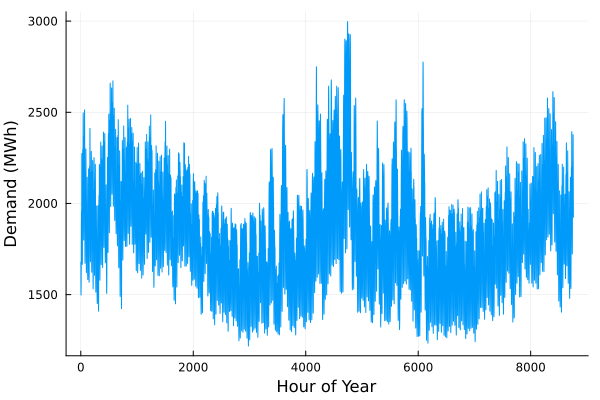

In [19]:
# load the data, pull Zone C, and reformat the DataFrame
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, :"Time Stamp" => :Date)
demand = NY_demand[:, [:Date, :C]]
rename!(demand, :C => :Demand)
demand[:, :Hour] = 1:nrow(demand)

# plot demand
plot(demand.Hour, demand.Demand, xlabel="Hour of Year", ylabel="Demand (MWh)", label=:false)

Next, we load the generator data, shown in
<a href="#tbl-generators" class="quarto-xref">Table 3</a>. This data
includes fixed costs (\$/MW installed), variable costs (\$/MWh
generated), and CO<sub>2</sub> emissions intensity (tCO<sub>2</sub>/MWh
generated).

In [16]:
gens = DataFrame(CSV.File("data/generators.csv"))

Row,Plant,FixedCost,VarCost,Emissions
,String15,Int64,Int64,Float64
1,Geothermal,450000,0,0.0
2,Coal,220000,24,1.0
3,NG CCGT,82000,30,0.43
4,NG CT,65000,40,0.55
5,Wind,91000,0,0.0
6,Solar,70000,0,0.0


Finally, we load the hourly solar and wind capacity factors, which are
plotted in <a href="#fig-cf" class="quarto-xref">Figure 2</a>. These
tell us the fraction of installed capacity which is expected to be
available in a given hour for generation (typically based on the average
meteorology).

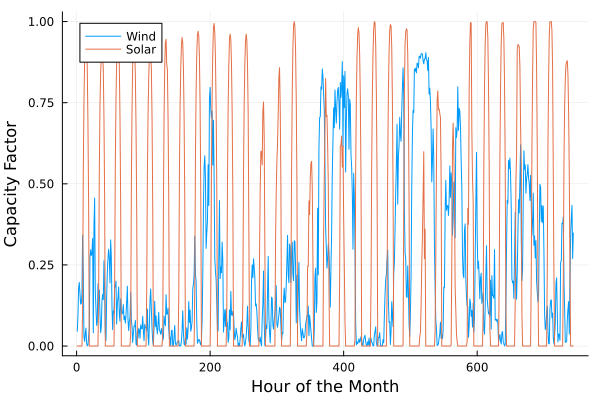

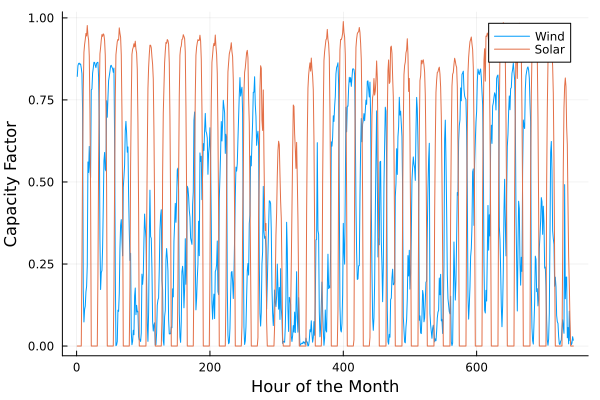

In [20]:
# load capacify factors into a DataFrame
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))

# plot January capacity factors
p1 = plot(cap_factor.Wind[1:(24*31)], label="Wind")
plot!(cap_factor.Solar[1:(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

p2 = plot(cap_factor.Wind[4344:4344+(24*31)], label="Wind")
plot!(cap_factor.Solar[4344:4344+(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

display(p1)
display(p2)

You have been asked to develop a generating capacity expansion plan for
the utility in Riley County, NY, which currently has no existing
electrical generation infrastructure. The utility can build any of the
following plant types: geothermal, coal, natural gas combined cycle gas
turbine (CCGT), natural gas combustion turbine (CT), solar, and wind.
The NY state legislature is planning to enact an annual CO<sub>2</sub>
limit, which for the utility would limit the emissions in its footprint
to 1.5 MtCO<sub>2</sub>/yr.

While coal, CCGT, and CT plants can generate at their full installed
capacity, geothermal plants operate at maximum 85% capacity, and solar
and wind available capacities vary by the hour depend on the expected
meteorology. The utility will also penalize any non-served demand at a
rate of \$10,000/MWh.

#### Problem 3.1

Formulate a linear program for this capacity expansion problem,
including clear definitions of decision variable(s) (including units),
objective function(s), and constraint(s) (make sure to explain functions
and constraints with any needed derivations and explanations).


In [26]:
gens = DataFrame(CSV.File("data/generators.csv"))
wind_cap = cap_factor.Wind      # hourly wind capacity facotrs 
solar_cap = cap_factor.Solar    # hourly solar cap. factors

fixed_cost = gens.FixedCost     # $/MW installed
var_cost = gens.VarCost         # $/MWh
co2_rate = gens.Emissions       # tons of CO₂ per MWh

NSE_Cost = 10_000               #$/MWh
G = 1:nrow(gens)                #generators 
T = 1:nrow(demand)              #hours in the year
CO2_lim = 1_500_000             #tCO2/year


energy_model = Model(HiGHS.Optimizer)
#define variables
@variables(energy_model, begin
    x[g in G] >= 0           # Installed capacity of generator g (MW)
    y[g in G, t in T] >= 0   # Generation in hour t by g (MWh)
    NSE[t in T] >= 0         # Unmet demand (MWh)
end)

#Minimize costs
@objective(energy_model, Min,
    sum(fixed_cost[g] * x[g] for g in G) +
    sum(var_cost[g] * y[g, t] for g in G, t in T) +
    NSE_Cost * sum(NSE[t] for t in T)
)

#Demand met, or becomes NSE
@constraint(energy_model, load_balance[t in T],
    sum(y[g, t] for g in G) + NSE[t] >= demand.Demand[t]
)

#Capacity limits (Wind, Solar, Geo)
@constraint(energy_model, wind_limit[g in G, t in T; gens[g, :Plant] == "Wind"],
    y[g, t] <= x[g] * wind_cap[t]
)
@constraint(energy_model, solar_limit[g in G, t in T; gens[g, :Plant] == "Solar"],
    y[g, t] <= x[g] * solar_cap[t]
)
@constraint(energy_model, geo_limit[g in G, t in T; gens[g, :Plant] == "Geothermal"],
    y[g, t] <= 0.85 * x[g]
)

# Capacity constraints for dispatchable plants (Coal, CCGT, CT)
@constraint(energy_model, dispatchable_cap[g in G, t in T;
    gens.Plant[g] ∉ ["Wind", "Solar", "Geothermal"]],
    y[g, t] <= x[g]
)

#CO2 Emissions Cap constraint
@constraint(energy_model, co2_cap,
    sum(co2_rate[g] * y[g, t] for g in G, t in T) <= CO2_lim
)

optimize!(energy_model);


Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 61321 rows; 61326 cols; 188256 nonzeros
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+06]
Presolving model
56857 rows, 56862 cols, 179328 nonzeros  0s
56854 rows, 56859 cols, 179322 nonzeros  0s
Presolve : Reductions: rows 56854(-4467); columns 56859(-4467); elements 179322(-8934)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(3.56131e+06) 0s
      26530     7.1866966237e+08 Pr: 7916(894919); Du: 0(5.22508e-06) 5s
      30978     7.8436578999e+08 Pr: 1588(45648.3); Du: 0(4.63825e-06) 10s
      31987     7.8535295894e+08 Pr: 0(0); Du: 0(8.32377e-11) 11s
Solving the original LP from the solution after postsolve
Model status        : Optimal
Simplex   iterations: 31987
Objective value     :  7.8535295894e+08

#### Problem 3.2

How much should the utility build of each type of generating plant? What
will the total cost be? How much energy will be non-served?

285.6 MW of Geothermal, 1509.2 MW of CCGT, 703.1 MW of CT, 2548.9 MW Wind, 2103.7 MW Solar.  
The total Cost = $785,352,958.94. Non-served energy = 121 MW

#### Problem 3.3

What fraction of annual generation does each plant type produce? How
does this compare to the breakdown of built capacity that you found in
Problem 3.2? Do these results make sense given the demand and generator
data?

The percent of annual production for each plant is shown in the final column in the chart below. This aligns somewhat with the breakdown of the built capacity, in that wind and solar have the most built capacity and provide the highest annual percentage. The NG CT plant does not account for even 1% of annual production, while geothermal accounts for almost 7% and has far less installed capacity. This makes sense because of the emissions from the NG CT plant, it is only used when nothing else will provide enough power, whereas the geothermal can run constantly with no emissions. 

In [42]:
### COPIED FROM CLASS SLIDES TO SUMMARIZE RESULTS ###

generation = zeros(size(G,1))
for i in 1:size(G,1) 
    generation[i] = sum(value.(y)[G[i],:].data) 
end
MWh_share = generation./sum(demand.Demand).*100
cap_share = value.(x).data ./ maximum(demand.Demand) .* 100
results = DataFrame(
    Resource = gens.Plant[G], 
    Capacity = value.(x).data,
    Percent_Cap = cap_share,
    Generated = generation/1000,
    Percent_Gen = MWh_share
)
rename!(results, 
    [:Capacity => :"Installed (MW)", 
    :Percent_Cap => :"Percent  (%)", 
    :Generated => "Generation (GWh)",
    :Percent_Gen => "Percent (%)"])
results[:, 2:end] = round.(results[:, 2:end], digits=1)

NSE_MW = maximum(value.(NSE).data) 
NSE_MWh = sum(value.(NSE).data)
push!(results, ["NSE" NSE_MW NSE_MW/maximum(demand.Demand)*100 NSE_MWh/1000 NSE_MWh/sum(demand.Demand)*100])

println("\nTotal Cost = \$", objective_value(energy_model))

results[:, 2:end] = round.(results[:, 2:end], digits=1)
markdown_table(results)


Total Cost = $7.853529589434901e8

| Resource   | Installed (MW) | Percent  (%) | Generation (GWh) | Percent (%) |
|------------|----------------|--------------|------------------|-------------|
| Geothermal |          285.6 |          9.5 |           1106.3 |         6.8 |
|       Coal |            0.0 |          0.0 |              0.0 |         0.0 |
|    NG CCGT |         1509.2 |         50.3 |           3322.8 |        20.3 |
|      NG CT |          703.1 |         23.5 |            129.5 |         0.8 |
|       Wind |         2548.9 |         85.0 |           6598.7 |        40.3 |
|      Solar |         2103.7 |         70.2 |           5210.7 |        31.8 |
|        NSE |          121.0 |          4.0 |              0.3 |         0.0 |


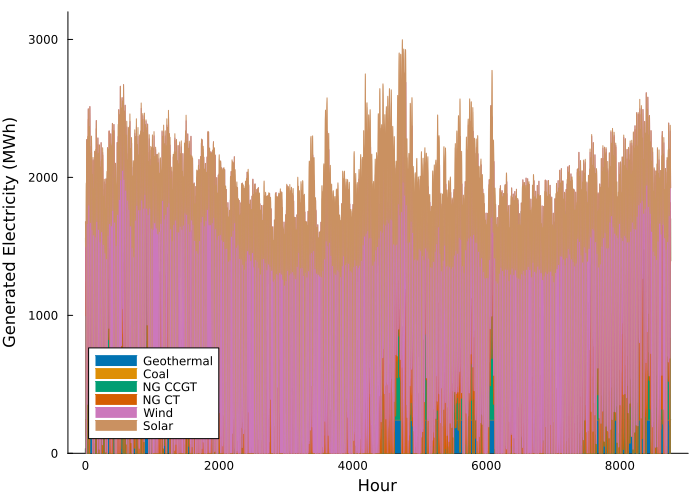

In [40]:
### ALSO COPIED FROM CLASS SLIDES ###
p2 = areaplot(value.(y).data', 
    label=permutedims(gens.Plant), 
    xlabel = "Hour", 
    ylabel ="Generated Electricity (MWh)", 
    color_palette=:seaborn_colorblind,
    grid=:false,
    legend = :bottomleft)
ylims!(p2, (0, 3200))
plot!(p2, size=(700, 500))

#### Problem 3.5

What is the shadow price of CO<sub>2</sub>? What is the value to the
utility be of allowing it to emit an additional 1000 tCO<sub>2</sub>/yr?

In [62]:
println("Shadow price of CO2 = \$", -shadow_price(co2_cap))
println("Value of relaxing CO2 by 1000 tCO2 = \$", -shadow_price(co2_cap)*1000)

Shadow price of CO2 = $182.77193609185855
Value of relaxing CO2 by 1000 tCO2 = $182771.93609185854


## References

I consulted the class slides, and code used there.